In [1]:
import json
import os
import pickle
import sys

import httpx
import matplotlib.pyplot as plt
import pandas as pd
import requests
import yaml
from dotenv import load_dotenv
from tqdm import tqdm


# Determine the project root directory for relative imports
try:
    # This will work in scripts where __file__ is defined
    current_dir = os.path.dirname(os.path.abspath(__file__))
    # Assuming "src" is parallel to the script folder
    project_root = os.path.abspath(os.path.join(current_dir, ".."))
except NameError:
    # In notebooks __file__ is not defined: assume we're in notebooks/riziv_dataset/
    project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

In [2]:
###############
# Load data
###############

# Define the path to the BSARD dataset files
BSARD_data_path = os.path.join(project_root, "data", "BSARD_dataset")

# BSARD main table
bsard_corpus_lean = pd.read_csv(os.path.join(BSARD_data_path, 'intermediate', "bsard_corpus_lean_B.csv"))
bsard_corpus_lean.drop(["Unnamed: 0"], inplace=True, axis=1)

# Keywords dict
keywords_dict_path = os.path.join(BSARD_data_path, 'intermediate', 'keyword_extraction.pkl')
with open(keywords_dict_path, 'rb') as f:
        keywords_dict = pickle.load(f)

###############
# Parse retrieved keyword-related content and build dataframe
###############

# Keep only those articles which have been already scanned
keywords_dict_filter = {k:v for k,v in keywords_dict.items() if v != None} 

parsed_key_terms = []

for art in keywords_dict_filter.keys():

    for n in ["1", "2", "3", "4"]:

        parsed_key_terms.append((art, keywords_dict_filter[art][f"key_concept_{n}"]))

# Build Dataframe
key_terms_df = pd.DataFrame(parsed_key_terms, columns=['article_code', 'key_term'])

In [3]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() > 1].head(25)

key_term
AWIPH                          256
Gouvernement                   138
Code décrétal                  131
assemblée générale             123
procès-verbal                  120
analyse des risques            114
procureur du Roi               113
tribunal de la famille         110
collège communal               107
demande d'agrément             102
amende administrative           97
personnes handicapées           95
agrément                        92
procureur général               92
juge de paix                    91
Agence                          87
pouvoir organisateur            86
ministère public                85
règlement d'ordre intérieur     82
enquête publique                79
autorité compétente             78
organe d'administration         76
prescription                    75
permis d'urbanisme              72
nullité                         68
Name: count, dtype: int64

In [4]:
# List of key terms identified at least twice during scanning

key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() > 1].value_counts()

count
2      5764
3      2115
4      1083
5       653
6       443
       ... 
58        1
55        1
54        1
38        1
256       1
Name: count, Length: 86, dtype: int64

In [5]:
# Total number of hits for key terms identified at least twice

key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() > 1].sum()


52511

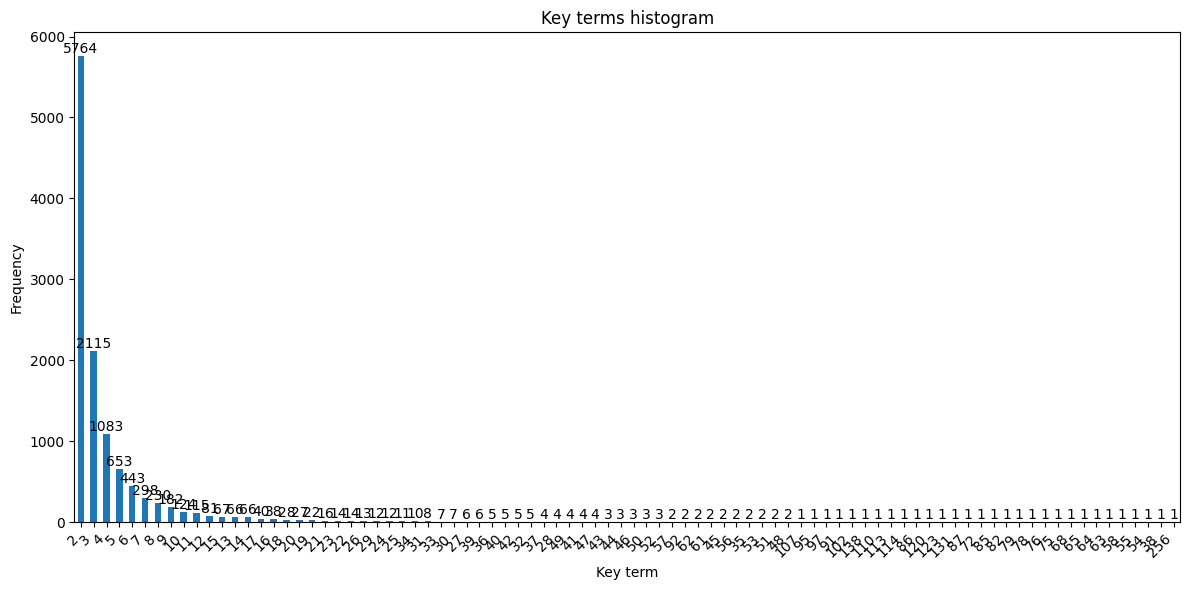

In [6]:
s = key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() > 1].value_counts()

ax = s.plot(kind='bar', figsize=(12, 6))

# Tags
for bar in ax.patches:
    heigth = int(bar.get_height())
    ax.annotate(
        str(heigth),                       # number of hits
        (bar.get_x() + bar.get_width()/2, heigth),  # position (center heigth)
        ha='center', va='bottom'          # alignment (horizontal - vertical)
    )

plt.xticks(rotation=45, ha='right')
plt.xlabel('Key term')
plt.ylabel('Frequency')
plt.title('Key terms histogram')
plt.tight_layout()
plt.show()


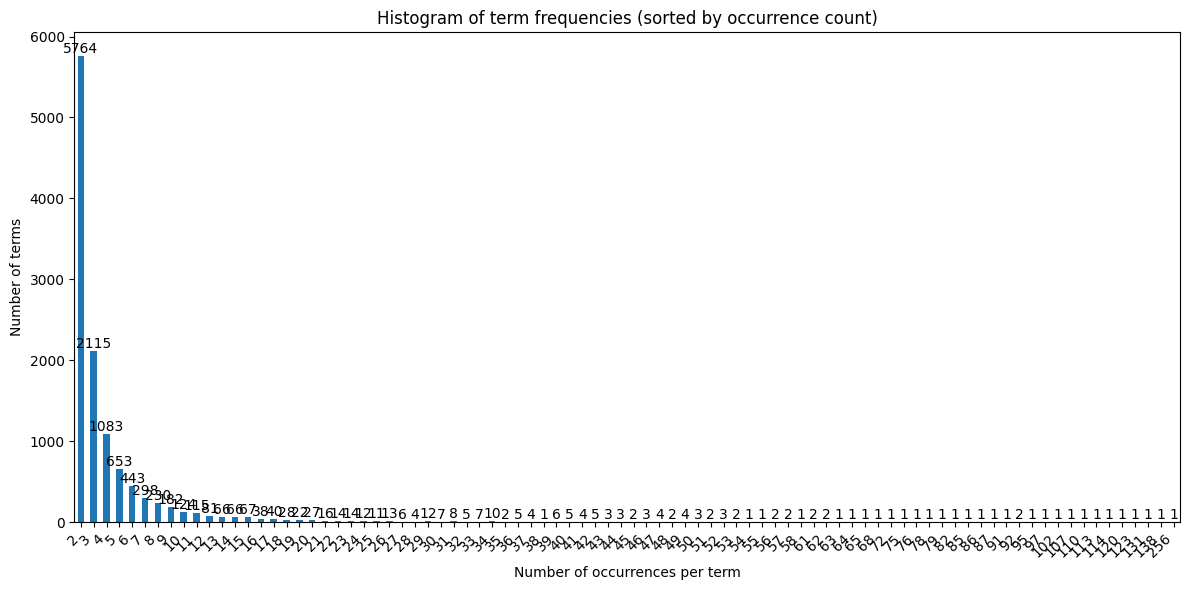

In [7]:
# 1) Count how many times each term appears
term_counts = key_terms_df["key_term"].value_counts()

# 2) Keep only the terms that appear more than once
filtered_counts = term_counts[term_counts > 1]

# 3) Build a “histogram” of those counts: 
#    i.e. how many terms have frequency 2, 3, 4, etc.
frequency_counts = filtered_counts.value_counts()

# 4) Sort by the frequency value (the index) so x-axis goes 2, 3, 4, …
frequency_counts = frequency_counts.sort_index()

# 5) Plot the bar chart
fig, ax = plt.subplots(figsize=(12, 6))
frequency_counts.plot(kind='bar', ax=ax)

# 6) Annotate each bar with its height
for bar in ax.patches:
    height = int(bar.get_height())
    ax.annotate(
        str(height),                              # show the count on top
        (bar.get_x() + bar.get_width() / 2, height),  # position: center top of each bar
        ha='center', va='bottom'
    )

# 7) Tidy up labels and title
ax.set_xticklabels(frequency_counts.index, rotation=45, ha='right')
ax.set_xlabel('Number of occurrences per term')
ax.set_ylabel('Number of terms')
ax.set_title('Histogram of term frequencies (sorted by occurrence count)')
plt.tight_layout()
plt.show()


In [8]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() > 1].sample(15) 

key_term
code de déontologie           4
garantie régionale            2
échelles de traitements       2
secrétaire                    3
folle enchère                 3
Arrêté ministériel            2
enfouissement                 2
émission d'actions            2
direction de l'école          2
signe monétaire               2
force majeure                30
contrôle de l'application     3
gestionnaire désigné          2
subvention (subvention)       3
arrêté d'exécution            2
Name: count, dtype: int64

In [9]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 10].head(25)

key_term
dispositions applicables                   10
diviseur électoral                         10
augmentation du capital                    10
contrôle administratif                     10
Sanction de niveau 2                       10
interdiction des droits                    10
audience                                   10
demande de permis                          10
apport en nature                           10
accès aux locaux                           10
Cour des marchés                           10
contrevenant                               10
Juge d'instruction                         10
Analyse des risques                        10
fusion transfrontalière                    10
procureur fédéral                          10
Convention CLC 1992                        10
contrefaçon                                10
subrogé tuteur                             10
statut pécuniaire                          10
services de santé mentale                  10
agence immobilière social

In [10]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 9].head(25)

key_term
paiement                                                    9
hypothèque légale                                           9
subvention spécifique                                       9
marchés publics                                             9
amiante                                                     9
journées de présence                                        9
Gestionnaire de l'infrastructure                            9
Tribunal de première instance                               9
Administration générale de la Documentation patrimoniale    9
garantie                                                    9
possession d'état                                           9
centres de coordination                                     9
démocratie locale                                           9
délit                                                       9
distributeur                                                9
opposabilité aux tiers                                      9

In [11]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 8].sample(25)

key_term
frais                              8
responsabilité du transporteur     8
héritier                           8
consignation                       8
notification au demandeur          8
Limitation de responsabilité       8
Employeur                          8
intercommunale                     8
sentence arbitrale                 8
atmosphères explosives             8
subvention forfaitaire annuelle    8
plans et programmes                8
relais social                      8
conventions de collaboration       8
arrêt                              8
magistrat EPE                      8
dossiers individuels               8
contribution financière            8
emprisonnement de huit jours       8
nullité de la décision             8
société en nom collectif           8
clôture de la liquidation          8
protêt                             8
lésion                             8
adoption simple                    8
Name: count, dtype: int64

In [12]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 7].head(25)

key_term
actionnaire                         7
évaluation annuelle                 7
échange d'informations              7
médecin coordinateur                7
consentement                        7
conciliation                        7
accord de partenariat commercial    7
services de paiement                7
disposition statutaire contraire    7
recours en cassation                7
échelles de traitement              7
délai de paiement                   7
règles                              7
autorité judiciaire                 7
choix du droit applicable           7
délai de décision                   7
remboursement des sommes            7
Région                              7
règlement de juges                  7
ordonnance du président             7
réparation collective               7
date de dépôt                       7
prise d'eau                         7
organisme d'intérêt public          7
infraction aux dispositions         7
Name: count, dtype: int64

In [13]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 6].head(25)

key_term
consentement préalable               6
expertise                            6
Etat membre de l'Union européenne    6
agent biologique                     6
Infractions                          6
entités liées                        6
situation patrimoniale               6
négligence                           6
filiation paternelle                 6
délégation de pouvoirs écrite        6
cours légal                          6
ascendants                           6
prestations                          6
Discrimination                       6
sursis                               6
communes fusionnées                  6
signification du jugement            6
Règlement (UE) 2016/679              6
stage judiciaire                     6
conseillers communaux                6
parents ou alliés                    6
exercice d'attribution               6
exercice comptable                   6
Contrôleurs de la navigation         6
responsabilité du propriétaire       6
Name: count, dty

In [14]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 5].head(25)

key_term
gouverneur de province              5
valeur du point                     5
juge saisi                          5
fonctionnaire général               5
commission consultative spéciale    5
héritiers réservataires             5
liberté d'expression                5
impartialité                        5
ETA                                 5
prime de fin d'année                5
travaux de démolition               5
politique foncière agricole         5
projet d'école                      5
action en rescision                 5
service résidentiel                 5
dettes                              5
Service général de l'inspection     5
oeuvre orpheline                    5
personne                            5
mandat d'amener                     5
intérêts légitimes                  5
donations entre-vifs                5
dépôt nécessaire                    5
dénonciation                        5
Bien-être au Travail                5
Name: count, dtype: int64

In [15]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 4].sample(25)

key_term
pratiques innovantes                          4
aptitudes suffisantes                         4
tableau de dépouillement                      4
droit d'accès à l'information                 4
irrecevabilité                                4
protection des animaux                        4
Parlement de communauté                       4
comptes-titres                                4
Chambre nationale des huissiers de justice    4
jurés suppléants                              4
exécuteurs testamentaires                     4
animaux d'élevage                             4
section                                       4
changement d'affectation                      4
contrôle sur place                            4
émancipation                                  4
unité de production                           4
autre Etat membre                             4
partage judiciaire                            4
tierce personne                               4
résidents                      

In [16]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 3].sample(25)

key_term
dissolution du régime                           3
expropriations pour cause d'utilité publique    3
centre hospitalier psychiatrique                3
parts sociales                                  3
intention de donner la mort                     3
sociétés anonymes                               3
Santé mentale                                   3
mise en séquestre                               3
valeur nominale                                 3
Registre des électeurs                          3
objet                                           3
places de court séjour                          3
conclusions                                     3
Cohabitation légale                             3
modification d'un élément                       3
expertise scientifique                          3
consultation sur place                          3
titre de voyage                                 3
emprunts obligataires                           3
créancier saisissant                     

In [17]:
len(key_terms_df[key_terms_df["key_term"] == "Société wallonne du Logement"]["article_code"].str.split(".").str[0].unique())

1

In [18]:
# Cuantas leyes distintas estan relacionadas en promedio con un key term?

# Falta aqui filtrar por longitud para eliminar los unos o ir solo a por conteos determinados

set_key_terms = set(key_terms_df["key_term"])

unique_acts = {}

for key_term in set_key_terms: # iterar por todos los key terms
    tmp_df = key_terms_df[key_terms_df["key_term"] == key_term] # DF filtrado para solo un key term
    uniq_acts_term = len(tmp_df["article_code"].str.split(".").str[0].unique()) # Numero de leyes distintas involucradas en un key term
    #print(key_term, uniq_acts_term)
    unique_acts[key_term]=uniq_acts_term

In [19]:
unique_acts_df = pd.DataFrame(unique_acts.items(), columns=['key_term', 'unique_acts'])

In [20]:
unique_acts_df["unique_acts"].value_counts().sort_index()

unique_acts
1     42867
2      3420
3       955
4       384
5       219
6       123
7        72
8        40
9        21
10       18
11        9
12       15
13       10
14        6
15        2
16        4
17        3
18        1
19        1
20        1
21        1
Name: count, dtype: int64